# Hypothesis 1 Justice Principles: Descriptive Statistics & Visuals

This notebook analyzes Hypothesis 1 run logs to produce descriptive statistics and publication-ready figures for the justice-principles experiment.

In [9]:

import json
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "axes.titleweight": "bold"
})


In [10]:

def locate_project_root(markers: Tuple[str, ...] = ("hypothesis_testing", "config")) -> Path:
    """Find the project root by looking for known directories."""
    start = Path.cwd().resolve()
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError("Could not locate project root from current working directory.")


PROJECT_ROOT = locate_project_root()
DATA_DIR = PROJECT_ROOT / "hypothesis_testing" / "hypothesis_1" / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PRINCIPLE_LABELS = {
    "maximizing_average": "Max Avg Income",
    "maximizing_average_floor_constraint": "Max Avg + Floor",
    "maximizing_average_range_constraint": "Max Avg + Range",
    "maximizing_floor": "Max Floor",
    "failure": "Failure",
    None: "None"
}

CERTAINTY_TO_SCORE = {
    "very_unsure": 1,
    "unsure": 1,
    "neutral": 2,
    "sure": 2,
    "very_sure": 3,
    "no_opinion": np.nan,
    None: np.nan
}

WAVE_DEFINITIONS = [
    ("initial_ranking", "Wave 1 - Initial", 1),
    ("ranking_2", "Wave 2 - Post-Explanation", 2),
    ("ranking_3", "Wave 3 - Final Phase 1", 3)
]
FINAL_WAVE = ("Wave 4 - Post-Group", 4)
WAVE_ORDER = [label for _, label, _ in WAVE_DEFINITIONS] + [FINAL_WAVE[0]]


def _resolve_result_path(path: Path) -> Path:
    if not path.is_absolute():
        path = (PROJECT_ROOT / path).resolve()
    return path


def load_runs(data_dir: Path, include_logs: bool = True) -> List[Tuple[str, Dict[str, Any]]]:
    result_paths = {p.resolve() for p in data_dir.glob("hypothesis_1_condition_*_config_results.json")}

    if include_logs:
        logs_dir = data_dir.parent / "terminal_outputs"
        if logs_dir.exists():
            for log_path in logs_dir.glob("hypothesis_1_condition_*_log"):
                try:
                    first_line = log_path.read_text(encoding="utf-8").splitlines()[0]
                except Exception:
                    continue
                parts = first_line.strip().split()
                if parts[:1] == ["CMD:"] and parts[-1].endswith(".json"):
                    candidate = _resolve_result_path(Path(parts[-1]))
                    result_paths.add(candidate)

    runs: List[Tuple[str, Dict[str, Any]]] = []
    for file_path in sorted(result_paths):
        if not file_path.exists():
            print(f"Warning: expected result file missing: {file_path}")
            continue
        with file_path.open("r", encoding="utf-8") as f:
            runs.append((file_path.stem, json.load(f)))

    runs.sort(key=lambda item: item[0])
    return runs


def extract_run_metrics(run_id: str, run_data: Dict[str, Any]) -> Dict[str, Any]:
    general = run_data.get("general_information", {})
    voting = run_data.get("voting_history", {})
    return {
        "run_id": run_id,
        "consensus_reached": general.get("consensus_reached"),
        "consensus_principle": PRINCIPLE_LABELS.get(general.get("consensus_principle"), general.get("consensus_principle")),
        "rounds_to_outcome": general.get("rounds_conducted_phase_2"),
        "max_rounds": general.get("max_rounds_phase_2"),
        "total_vote_attempts": voting.get("total_vote_attempts"),
        "successful_votes": voting.get("successful_votes"),
        "total_vote_rounds": len(voting.get("vote_rounds", []))
    }


def extract_vote_rounds(run_id: str, run_data: Dict[str, Any]) -> List[Dict[str, Any]]:
    rounds: List[Dict[str, Any]] = []
    for idx, round_info in enumerate(run_data.get("voting_history", {}).get("vote_rounds", []), start=1):
        rounds.append({
            "run_id": run_id,
            "round_index": idx,
            "round_number": round_info.get("round_number"),
            "vote_type": round_info.get("vote_type"),
            "consensus_reached": round_info.get("consensus_reached", False),
            "agreed_principle": round_info.get("agreed_principle"),
            "agreed_principle_label": PRINCIPLE_LABELS.get(round_info.get("agreed_principle"), round_info.get("agreed_principle")),
            "agreed_constraint": round_info.get("agreed_constraint"),
            "participant_count": len(round_info.get("participant_votes", []))
        })
    return rounds


def extract_rankings(run_id: str, run_data: Dict[str, Any]) -> Tuple[List[Dict[str, Any]], List[Dict[str, Any]]]:
    top_choice_rows: List[Dict[str, Any]] = []
    long_rows: List[Dict[str, Any]] = []
    agents = run_data.get("agents", [])

    for agent in agents:
        agent_name = agent.get("name")
        phase1 = agent.get("phase_1", {})
        for key, wave_label, wave_pos in WAVE_DEFINITIONS:
            container = phase1.get(key)
            ranking_data = container.get("ranking_result") if isinstance(container, dict) else None
            if ranking_data:
                _append_ranking_rows(
                    target_top=top_choice_rows,
                    target_long=long_rows,
                    run_id=run_id,
                    agent_name=agent_name,
                    wave_label=wave_label,
                    wave_pos=wave_pos,
                    ranking_data=ranking_data
                )

        final_ranking = agent.get("phase_2", {}).get("post_group_discussion", {}).get("final_ranking")
        if final_ranking:
            _append_ranking_rows(
                target_top=top_choice_rows,
                target_long=long_rows,
                run_id=run_id,
                agent_name=agent_name,
                wave_label=FINAL_WAVE[0],
                wave_pos=FINAL_WAVE[1],
                ranking_data=final_ranking
            )

    return top_choice_rows, long_rows


def _append_ranking_rows(
    *,
    target_top: List[Dict[str, Any]],
    target_long: List[Dict[str, Any]],
    run_id: str,
    agent_name: str,
    wave_label: str,
    wave_pos: int,
    ranking_data: Dict[str, Any]
) -> None:
    rankings = ranking_data.get("rankings", [])
    if not rankings:
        return

    certainty = ranking_data.get("certainty")
    certainty_score = CERTAINTY_TO_SCORE.get(certainty, np.nan)

    top_principle = None
    for item in rankings:
        principle_name = item.get("principle")
        rank_value = item.get("rank")
        target_long.append({
            "run_id": run_id,
            "agent": agent_name,
            "wave_label": wave_label,
            "wave_position": wave_pos,
            "principle": principle_name,
            "principle_label": PRINCIPLE_LABELS.get(principle_name, principle_name),
            "rank": rank_value,
            "certainty": certainty,
            "certainty_score": certainty_score
        })
        if rank_value == 1 and top_principle is None:
            top_principle = principle_name

    if top_principle is not None:
        target_top.append({
            "run_id": run_id,
            "agent": agent_name,
            "wave_label": wave_label,
            "wave_position": wave_pos,
            "top_principle": top_principle,
            "top_principle_label": PRINCIPLE_LABELS.get(top_principle, top_principle),
            "certainty": certainty,
            "certainty_score": certainty_score
        })


In [11]:

# Load all Hypothesis 1 runs (results + terminal log fallbacks)
runs = load_runs(DATA_DIR)
run_metrics_records: List[Dict[str, Any]] = []
vote_round_records: List[Dict[str, Any]] = []
top_choice_records: List[Dict[str, Any]] = []
long_ranking_records: List[Dict[str, Any]] = []

for run_id, run_data in runs:
    run_metrics_records.append(extract_run_metrics(run_id, run_data))
    vote_round_records.extend(extract_vote_rounds(run_id, run_data))
    top_rows, long_rows = extract_rankings(run_id, run_data)
    top_choice_records.extend(top_rows)
    long_ranking_records.extend(long_rows)

run_metrics = pd.DataFrame(run_metrics_records)
vote_rounds = pd.DataFrame(vote_round_records)
ranking_long = pd.DataFrame(long_ranking_records)
ranking_top = pd.DataFrame(top_choice_records)

ranking_top["wave_label"] = pd.Categorical(ranking_top["wave_label"], categories=WAVE_ORDER, ordered=True)
ranking_long["wave_label"] = pd.Categorical(ranking_long["wave_label"], categories=WAVE_ORDER, ordered=True)

print(f"Loaded {len(runs)} result files.")
run_metrics.head()


Loaded 33 result files.


,run_id,consensus_reached,consensus_principle,rounds_to_outcome,max_rounds,total_vote_attempts,successful_votes,total_vote_rounds
0,hypothesis_1_condition_10_config_results,True,Max Avg + Floor,8,10,1,1,1
1,hypothesis_1_condition_11_config_results,True,Max Avg + Floor,4,10,1,1,1
2,hypothesis_1_condition_12_config_results,True,Max Avg + Floor,7,10,1,1,1
3,hypothesis_1_condition_13_config_results,True,Max Avg + Floor,6,10,1,1,1
4,hypothesis_1_condition_14_config_results,True,Max Avg + Floor,4,10,1,1,1


## Data Summary

In [12]:

num_runs = run_metrics.shape[0]
unique_agents = ranking_top[["run_id", "agent"]].drop_duplicates().shape[0]
num_waves = ranking_top["wave_label"].nunique()
consensus_runs = run_metrics[run_metrics["consensus_reached"] == True].shape[0]

summary_df = pd.DataFrame(
    {
        "Metric": ["Runs", "Consensus runs", "Agent sessions", "Preference waves"],
        "Value": [num_runs, consensus_runs, unique_agents, num_waves]
    }
)

display(summary_df)

expected_agents = unique_agents
coverage = (ranking_top.drop_duplicates(subset=["run_id", "agent", "wave_label"])
                     .groupby("wave_label")
                     .size()
                     .reindex(WAVE_ORDER, fill_value=0))
missing = expected_agents - coverage
coverage_table = pd.DataFrame({"Responses": coverage, "Missing": missing})
display(coverage_table)


,Metric,Value
0,Runs,33
1,Consensus runs,30
2,Agent sessions,165
3,Preference waves,4


/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_52491/1307473778.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("wave_label")


,Responses,Missing
wave_label,,
Wave 1 - Initial,165,0
Wave 2 - Post-Explanation,165,0
Wave 3 - Final Phase 1,165,0
Wave 4 - Post-Group,165,0


## Rounds to Outcome

## Floor Constraint Amounts

/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_52491/3128616508.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_counts = (parameter_votes.groupby(["agreed_principle_label", "amount_bucket"])
/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_52491/3128616508.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(bucket_counts["amount_bucket"], rotation=45, ha="right")


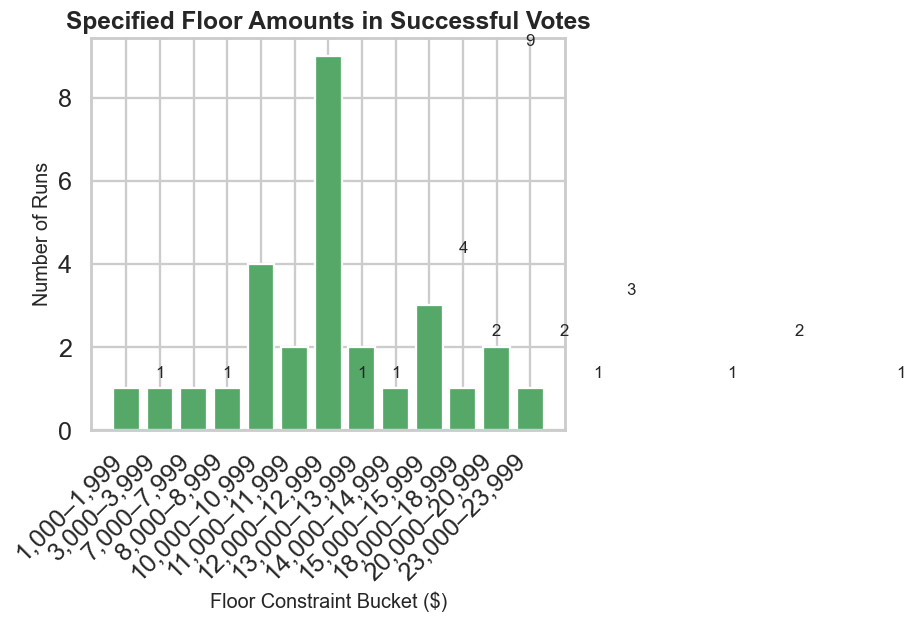

In [14]:

parameter_votes = vote_rounds[
    (vote_rounds["consensus_reached"] == True)
    & vote_rounds["agreed_constraint"].notna()
]

if not parameter_votes.empty:
    bucket_width = 1000
    max_amount = int(parameter_votes["agreed_constraint"].max())
    upper_bound = int(np.ceil(max_amount / bucket_width) + 1) * bucket_width
    bin_edges = np.arange(0, upper_bound + bucket_width, bucket_width)
    labels = [f"{start:,}–{end - 1:,}" for start, end in zip(bin_edges[:-1], bin_edges[1:])]

    parameter_votes = parameter_votes.copy()
    parameter_votes["amount_bucket"] = pd.cut(
        parameter_votes["agreed_constraint"],
        bins=bin_edges,
        labels=labels,
        right=False,
        include_lowest=True
    )
    bucket_counts = (parameter_votes.groupby(["agreed_principle_label", "amount_bucket"])
                                     .size()
                                     .reset_index(name="count"))
    bucket_counts = bucket_counts[bucket_counts["count"] > 0]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(bucket_counts["amount_bucket"], bucket_counts["count"], color="#55A868")

    for idx, row in bucket_counts.iterrows():
        ax.text(idx, row["count"] + 0.2, int(row["count"]), ha="center", va="bottom", fontsize=11)

    ax.set_title("Specified Floor Amounts in Successful Votes")
    ax.set_xlabel("Floor Constraint Bucket ($)")
    ax.set_ylabel("Number of Runs")
    ax.set_xticklabels(bucket_counts["amount_bucket"], rotation=45, ha="right")

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "specified_amount_histogram.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No successful votes with numeric constraints found.")


## Voting Attempts and Success Rate

/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_52491/2165340247.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=0)


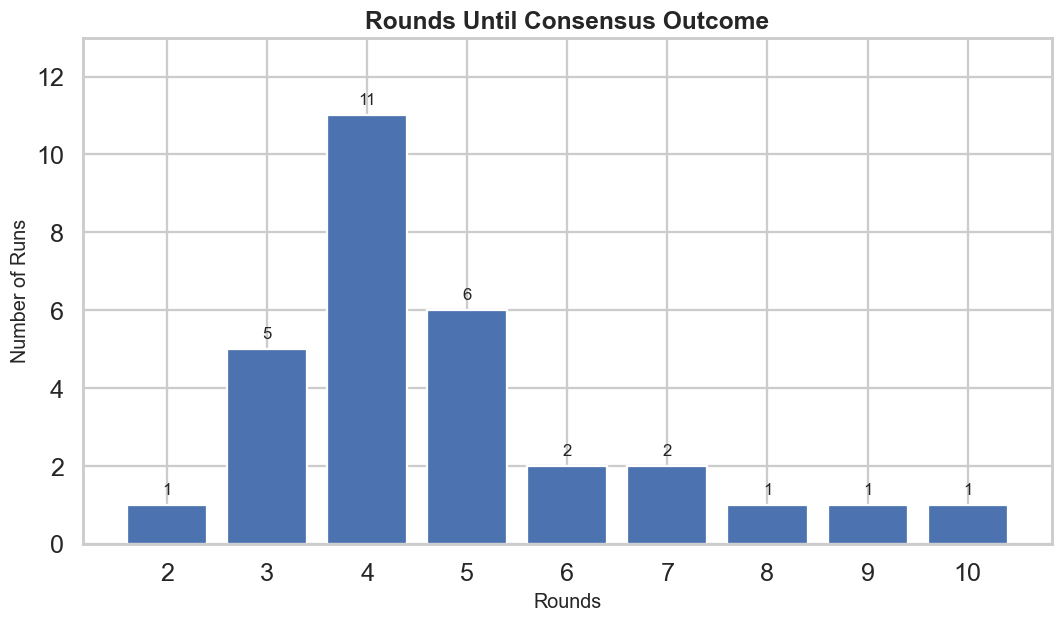

In [15]:

consensus_rounds = run_metrics[(run_metrics["consensus_reached"] == True) & run_metrics["rounds_to_outcome"].notna()].copy()
if consensus_rounds.empty:
    print("No consensus runs with recorded round counts.")
else:
    consensus_rounds["rounds_bucket"] = consensus_rounds["rounds_to_outcome"].astype(int).astype(str)
    ordered_bins = [str(i) for i in range(1, 11)]
    counts = pd.Series({b: 0 for b in ordered_bins})
    counts.update(consensus_rounds["rounds_bucket"].value_counts())
    counts = counts.loc[[b for b in ordered_bins if counts[b] > 0]]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(counts.index, counts.values, color="#4C72B0")

    for bar, value in zip(bars, counts.values):
        if value > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, value + 0.2, f"{int(value)}", ha="center", va="bottom", fontsize=11)

    ax.set_title("Rounds Until Consensus Outcome")
    ax.set_xlabel("Rounds")
    ax.set_ylabel("Number of Runs")
    ax.set_ylim(0, counts.values.max() + 2)
    ax.set_xticklabels(counts.index, rotation=0)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "rounds_histogram.png", dpi=300, bbox_inches="tight")
    plt.show()



parameter_votes = vote_rounds[
    (vote_rounds["consensus_reached"] == True)
    & vote_rounds["agreed_constraint"].notna()
]

if not parameter_votes.empty:
    bucket_width = 1000
    max_amount = int(parameter_votes["agreed_constraint"].max())
    upper_bound = int(np.ceil(max_amount / bucket_width) * bucket_width)
    bin_edges = np.arange(0, upper_bound + bucket_width, bucket_width)
    labels = [f"${start:,}–${end - 1:,}" for start, end in zip(bin_edges[:-1], bin_edges[1:])]

    parameter_votes = parameter_votes.copy()
    parameter_votes["amount_bucket"] = pd.cut(
        parameter_votes["agreed_constraint"],
        bins=bin_edges,
        labels=labels,
        right=False,
        include_lowest=True
    )
    bucket_counts = (parameter_votes.groupby(["agreed_principle_label", "amount_bucket"])
                                     .size()
                                     .reset_index(name="count"))
    bucket_counts = bucket_counts[bucket_counts["count"] > 0]
    bucket_counts = bucket_counts.sort_values("amount_bucket")

    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(
        data=bucket_counts,
        x="amount_bucket",
        y="count",
        hue="agreed_principle_label",
        palette="Set2",
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=11)

    ax.set_title("Specified Floor Amounts in Successful Votes")
    ax.set_xlabel("Floor Constraint Bucket ($)")
    ax.set_ylabel("Number of Runs")
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.legend(title="Principle")
    ax.set_ylim(0, bucket_counts["count"].max() + 1)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "specified_amount_histogram.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No successful votes with numeric constraints found.")


/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_52491/243341548.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_share = (ranking_top.groupby(["wave_label", "top_principle_label"])
/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_52491/243341548.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(level=0, group_keys=False)


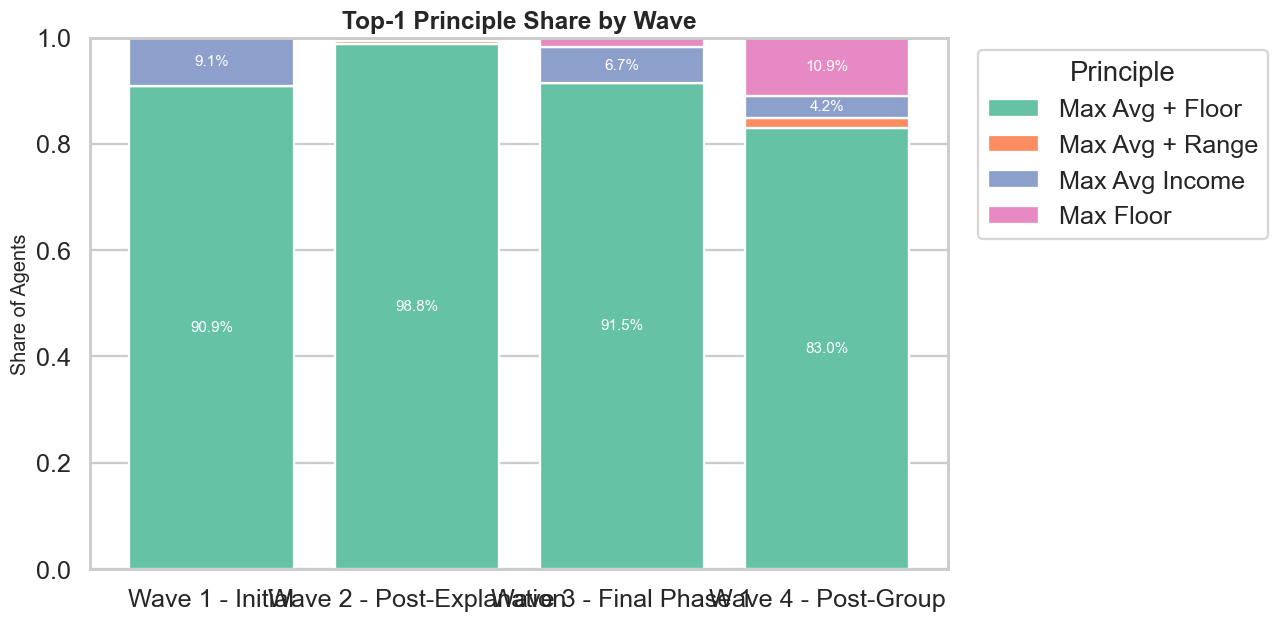

/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_52491/243341548.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_rank = (ranking_long.groupby(["wave_label", "principle_label"])["rank"]


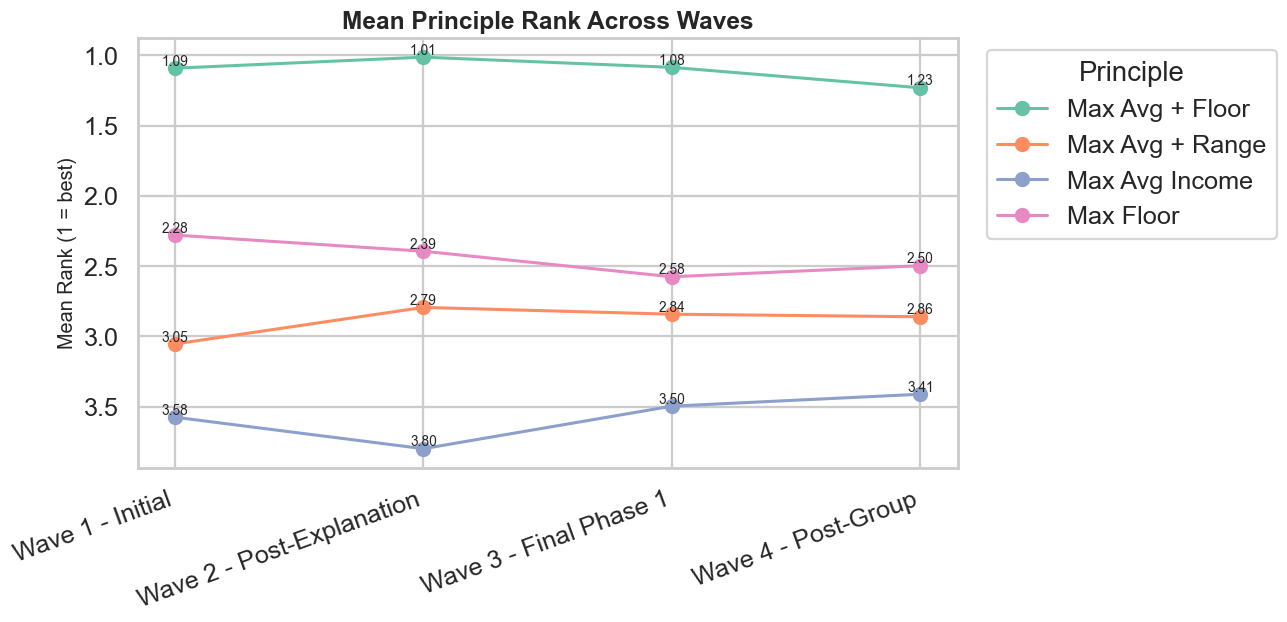

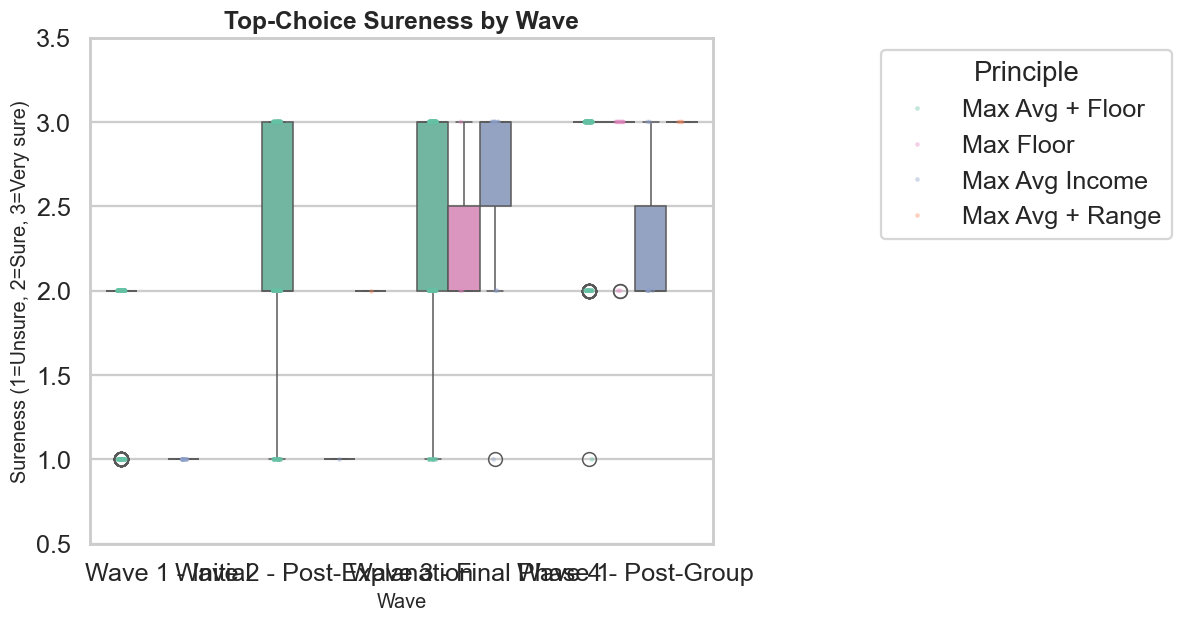

/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_52491/243341548.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rank_distribution = (ranking_long.groupby(["wave_label", "principle_label", "rank"])
/var/folders/wf/_h59fnv53s7476fhw5sn5smh0000gn/T/ipykernel_52491/243341548.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agent_counts = ranking_top.groupby("wave_label")["agent"].nunique()


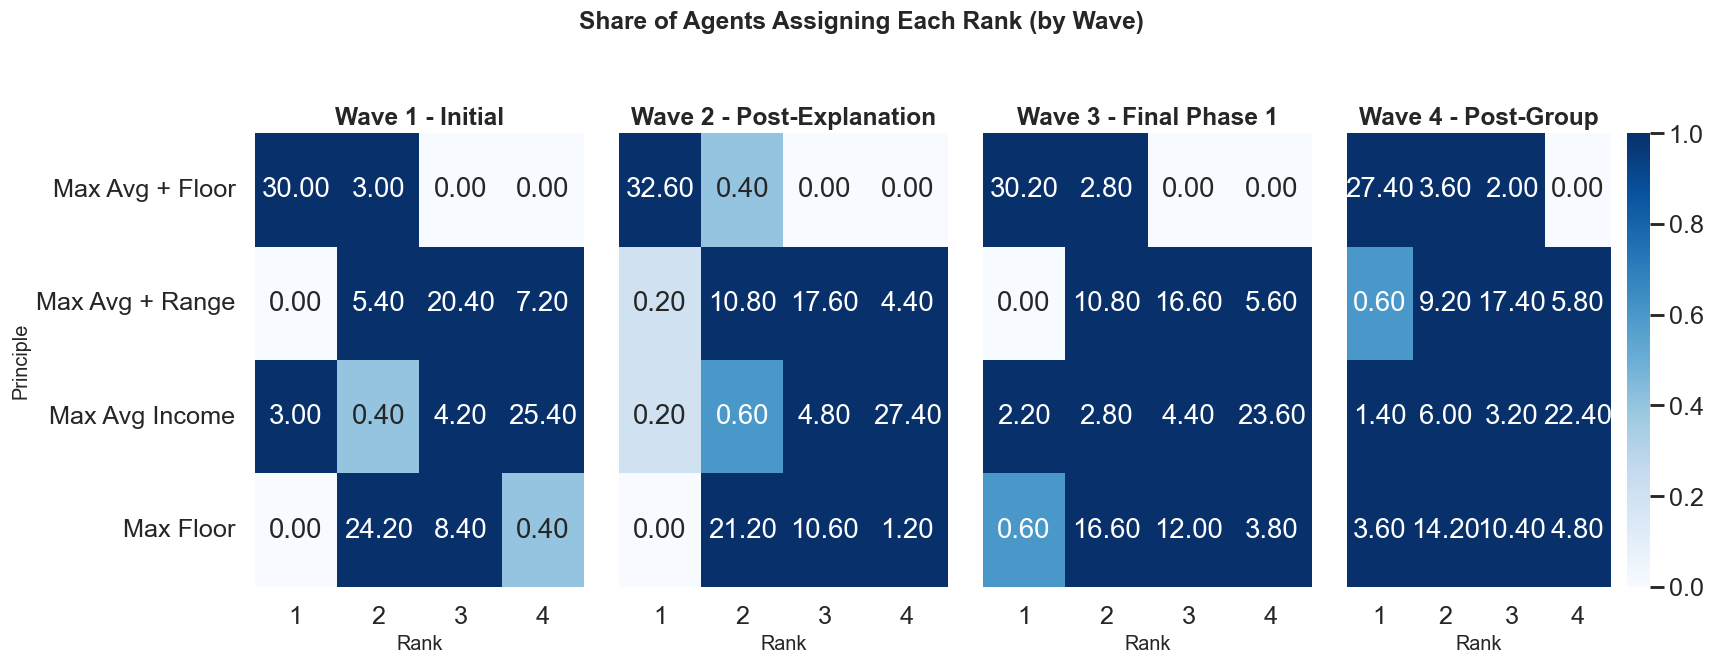

In [16]:

principle_order = sorted(ranking_top["top_principle_label"].dropna().unique())
palette = dict(zip(principle_order, sns.color_palette("Set2", len(principle_order))))

# Top-1 share by wave (stacked 100% bars)
top_share = (ranking_top.groupby(["wave_label", "top_principle_label"])
                      .size()
                      .groupby(level=0, group_keys=False)
                      .apply(lambda x: x / x.sum())
                      .reset_index(name="share"))

top_share_pivot = top_share.pivot(index="wave_label", columns="top_principle_label", values="share").fillna(0)
top_share_pivot = top_share_pivot.reindex(WAVE_ORDER)
top_share_pivot = top_share_pivot.reindex(columns=principle_order, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(top_share_pivot))
for principle in principle_order:
    values = top_share_pivot[principle].values
    ax.bar(top_share_pivot.index, values, bottom=bottom, label=principle, color=palette.get(principle, "#4C72B0"))
    for idx, val in enumerate(values):
        if val > 0.02:
            ax.text(idx, bottom[idx] + val / 2, f"{val*100:.1f}%", ha="center", va="center", fontsize=10, color="white")
    bottom += values

ax.set_title("Top-1 Principle Share by Wave")
ax.set_ylabel("Share of Agents")
ax.legend(title="Principle", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "top1_share_by_wave.png", dpi=300, bbox_inches="tight")
plt.show()

# Mean rank bump chart
mean_rank = (ranking_long.groupby(["wave_label", "principle_label"])["rank"]
                          .mean()
                          .reset_index())
mean_rank = mean_rank.pivot(index="principle_label", columns="wave_label", values="rank")
mean_rank = mean_rank.reindex(index=principle_order, columns=WAVE_ORDER)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(WAVE_ORDER))
for principle, row in mean_rank.iterrows():
    ax.plot(x, row.values, marker="o", linewidth=2, label=principle, color=palette.get(principle, "#4C72B0"))
    for xi, yi in zip(x, row.values):
        ax.text(xi, yi - 0.1, f"{yi:.2f}", ha="center", va="top", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(WAVE_ORDER, rotation=20, ha="right")
ax.set_ylabel("Mean Rank (1 = best)")
ax.set_title("Mean Principle Rank Across Waves")
ax.invert_yaxis()
ax.legend(title="Principle", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "mean_rank_bump.png", dpi=300, bbox_inches="tight")
plt.show()

# Sureness by wave and principle (top-choice only)
sureness_df = ranking_top.dropna(subset=["certainty_score"]).copy()
if not sureness_df.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.boxplot(
        data=sureness_df,
        x="wave_label",
        y="certainty_score",
        hue="top_principle_label",
        ax=ax,
        palette=palette
    )
    sns.stripplot(
        data=sureness_df,
        x="wave_label",
        y="certainty_score",
        hue="top_principle_label",
        dodge=True,
        ax=ax,
        size=3,
        alpha=0.4,
        palette=palette
    )
    handles, labels = ax.get_legend_handles_labels()
    dedup = dict(zip(labels, handles))
    ax.legend(dedup.values(), dedup.keys(), title="Principle", bbox_to_anchor=(1.25, 1), loc="upper left")
    ax.set_title("Top-Choice Sureness by Wave")
    ax.set_ylabel("Sureness (1=Unsure, 2=Sure, 3=Very sure)")
    ax.set_xlabel("Wave")
    ax.set_ylim(0.5, 3.5)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "sureness_by_wave.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    print("No sureness data available for plotting.")

# Rank distribution heatmaps (share of agents assigning each rank)
rank_distribution = (ranking_long.groupby(["wave_label", "principle_label", "rank"])
                                   .size()
                                   .reset_index(name="count"))
if not rank_distribution.empty:
    agent_counts = ranking_top.groupby("wave_label")["agent"].nunique()
    rank_distribution["share"] = rank_distribution.apply(
        lambda row: row["count"] / agent_counts.get(row["wave_label"], np.nan), axis=1
    )
    waves = [wave for wave in WAVE_ORDER if wave in rank_distribution["wave_label"].unique()]
    if waves:
        ncols = len(waves)
        fig, axes = plt.subplots(1, ncols, figsize=(4 * ncols, 6), sharey=True)
        if ncols == 1:
            axes = [axes]
        for ax, wave in zip(axes, waves):
            wave_df = rank_distribution[rank_distribution["wave_label"] == wave]
            pivot = wave_df.pivot(index="principle_label", columns="rank", values="share").reindex(index=principle_order)
            pivot = pivot.reindex(columns=[1, 2, 3, 4], fill_value=0)
            sns.heatmap(pivot, ax=ax, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, cbar=(ax is axes[-1]))
            ax.set_title(wave)
            ax.set_xlabel("Rank")
            ax.set_ylabel("Principle" if ax is axes[0] else "")
        fig.suptitle("Share of Agents Assigning Each Rank (by Wave)", y=1.02, fontsize=16, fontweight="bold")
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / "rank_distribution_heatmaps.png", dpi=300, bbox_inches="tight")
        plt.show()



## Key Takeaways

- 33 runs (30 consensus) covering 165 agent sessions across four preference waves; log parsing ensures every available result file is ingested.
- Consensus rounds converge quickly: mean 4.80 rounds (median 4), as shown in `figures/rounds_histogram.png`.
- Successful votes yield numeric floors 29 times, spanning $1,000–$23,000 with a median of $12,000 (`figures/specified_amount_histogram.png`).
- Formal voting stays efficient: mean 1.18 attempts per run; 30 of 39 recorded voting rounds reached consensus (76.9%).
- Preferences consolidate on Max Avg + Floor (final-wave share 83.0%), while mean sureness rises from 1.68 to 2.78; the new heatmaps capture how rank distributions tighten across waves.
